# Experiment: exp_kuramoto_gis

这个 notebook 把 `Kuramoto` 数据、`GIS` 数据驱动主流程、互信息占比分析和频谱分析统一到一条实验链上，重点比较微观观测层与宏观粗粒化层的动态效率、预测闭合性和信息保留情况。


## 0.1 Notebook 目标与结构说明

实验目标是：在 `Kuramoto` 振子系统上，先建立观测层微观 `GIS`，再构造宏观变量并比较两层的 `J_alpha`、预测误差和 `CE`，最后补充互信息占比与频谱分析。

整体分成三段：
1. 第一部分走完整 `GIS` 主流程。
2. 第二部分加入 `Kuramoto` 旧实验特有的互信息和频谱分析。
3. 第三部分统一汇总结论。


In [1]:
NOTEBOOK_SECTIONS = {
    '0': '公共准备：目标、依赖、参数与专用函数',
    '1': '主流程：含噪 Kuramoto 数据上的 GIS 宏微比较',
    '2': '实验特有部分：互信息占比与频谱分析',
    '3': '统一摘要：汇总结论',
}
for key, value in NOTEBOOK_SECTIONS.items():
    print(f'{key}. {value}')


0. 公共准备：目标、依赖、参数与专用函数
1. 主流程：含噪 Kuramoto 数据上的 GIS 宏微比较
2. 实验特有部分：互信息占比与频谱分析
3. 统一摘要：汇总结论


## 0.2 公共依赖、绘图风格与统一参数

这里完成三件事：导入依赖、统一中文绘图风格、固定实验参数。后面所有单元都默认引用这里的配置，避免在不同代码块里重复写死参数。


In [2]:
import sys
from pathlib import Path

REPO_ROOT = None
for candidate in [Path.cwd(), Path.cwd().parent, Path.cwd().parent.parent]:
    if (candidate / 'tools' / 'tools.py').exists():
        REPO_ROOT = candidate
        break
if REPO_ROOT is None:
    raise RuntimeError('Could not locate repository root containing tools/tools.py')
if str(REPO_ROOT) not in sys.path:
    sys.path.append(str(REPO_ROOT))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import pysindy as ps
from IPython.display import display

from tools import (
    add_gaussian_noise, prepare_time_pairs, fit_linear_gis_from_pairs,
    compute_gis_metrics, compute_prediction_errors, compute_ce_from_micro_macro,
    select_macro_rank, build_w_from_svd, apply_coarse_graining,
    summarize_pipeline_results, fit_data_koopman_operator, init_artifacts,
)
from data.data_func import plot_clustered_kuramoto

sns.set_theme(style='whitegrid')
plt.rcParams['figure.dpi'] = 120
plt.rcParams['savefig.dpi'] = 160
plt.rcParams['axes.unicode_minus'] = False
plt.rcParams['font.sans-serif'] = ['Microsoft YaHei', 'SimHei', 'Noto Sans CJK SC', 'DejaVu Sans']
HEATMAP_CMAP = 'vlag'

config = {
    'experiment_name': 'exp_kuramoto_gis',
    'observable_mode': 'identity + fourier',
    'n_fourier_frequencies': 1,
    'burn_in_steps': 1000,
    'sample_stride': 10,
    'lag_steps': 12,
    'alpha': 1.0,
    'eps': 1e-10,
    'ridge': 1e-10,
    'noise_scale': 0.03,
    'noise_seed': 42,
    'manual_r': 2,
    'horizons': (1, 3, 5),
    'micro_label_step': 4,
    'matrix_figsize': (7, 6),
    'selected_micro_indices': [0, 5, 10, 15],
    'selected_feature_plot_indices': [0, 1, 20],
    'curve_window': 180,
    'kuramoto': {
        'N': 10, 'n_clusters': 2, 'K_intra': 5.0, 'K_inter': 0.07,
        'noise': 0.0, 'T': 100.0, 'dt': 0.01, 'random_seed1': 0, 'random_seed2': 0,
    },
}
artifacts = init_artifacts(config)
display(pd.DataFrame([{'experiment_name': config['experiment_name'], 'noise_scale': config['noise_scale'], 'lag_steps': config['lag_steps'], 'manual_r': config['manual_r']}]))


,experiment_name,noise_scale,lag_steps,manual_r
0,exp_kuramoto_gis,0.03,12,2


## 0.3 公共函数区（本实验特有的，不包括复用 `tools.py` 里面的函数）

这里集中放 notebook 自己需要的辅助函数，主要负责三件事：高维矩阵稀疏标签绘图、`identity + fourier` 观测与频谱分析、互信息占比与 `K_bar` 特征分解辅助宏观变量构造。


In [3]:
def sparse_labels(labels, step=1):
    if labels is None:
        return False
    if step <= 1:
        return labels
    return [label if i % step == 0 else '' for i, label in enumerate(labels)]

def plot_matrix_heatmap(matrix, title, row_labels=None, col_labels=None, center=0.0, figsize=(6, 6), label_step=1, cmap=HEATMAP_CMAP):
    matrix = np.asarray(matrix)
    fig, ax = plt.subplots(figsize=figsize)
    sns.heatmap(matrix, ax=ax, cmap=cmap, center=center, square=matrix.shape[0] == matrix.shape[1], xticklabels=sparse_labels(col_labels, label_step), yticklabels=sparse_labels(row_labels, label_step))
    ax.set_title(title)
    plt.tight_layout(); plt.show()

def plot_dual_singular_spectra(sv_forward, sv_backward, title, forward_label='????', backward_label='????', forward_color='#4C78A8', backward_color='#F58518'):
    sv_forward = np.asarray(sv_forward, dtype=float)
    sv_backward = np.asarray(sv_backward, dtype=float)
    n = max(len(sv_forward), len(sv_backward))
    idx = np.arange(1, n + 1)
    f_vals = np.full(n, np.nan)
    b_vals = np.full(n, np.nan)
    f_vals[:len(sv_forward)] = sv_forward
    b_vals[:len(sv_backward)] = sv_backward

    width = 0.38
    fig, ax = plt.subplots(figsize=(8, 4.5))
    ax.bar(idx - width / 2, f_vals, width=width, color=forward_color, alpha=0.45, label=forward_label)
    ax.bar(idx + width / 2, b_vals, width=width, color=backward_color, alpha=0.45, label=backward_label)
    ax.plot(idx - width / 2, f_vals, color=forward_color, marker='o', linewidth=1.8)
    ax.plot(idx + width / 2, b_vals, color=backward_color, marker='o', linewidth=1.8)
    ax.set_title(title)
    ax.set_xlabel('????')
    ax.set_ylabel('????')
    ax.set_xticks(idx)
    ax.legend()
    plt.tight_layout(); plt.show()

def standardize_for_plot(x):
    x = np.asarray(x, dtype=float)
    return (x - np.mean(x)) / (np.std(x) + 1e-12)

def observable_identity_fourier(data, state_names, n_frequencies=1):
    library = ps.IdentityLibrary() + ps.FourierLibrary(n_frequencies=n_frequencies)
    library.fit(data)
    lifted = np.asarray(library.transform(data), dtype=float)
    return {'library': library, 'data': lifted, 'feature_names': library.get_feature_names(input_features=list(state_names))}

def compute_cluster_order_parameter_series(theta, n_clusters):
    theta = np.asarray(theta, dtype=float)
    n_total = theta.shape[1]
    cluster_size = n_total // n_clusters
    series, labels = [], []
    for c in range(n_clusters):
        start = c * cluster_size
        end = n_total if c == n_clusters - 1 else (c + 1) * cluster_size
        series.append(np.abs(np.mean(np.exp(1j * theta[:, start:end]), axis=1)))
        labels.append(f'? {c + 1} ???')
    return np.column_stack(series), labels

def compute_fft_spectrum(signal, dt, remove_dc=True, standardize=False):
    work = np.asarray(signal, dtype=float).copy()
    if standardize:
        work = standardize_for_plot(work)
    if remove_dc:
        work = work - np.mean(work)
    n_signal = work.shape[0]
    fft_vals = np.fft.fft(work)
    freqs = np.fft.fftfreq(n_signal, d=dt)
    mask = freqs >= 0
    freqs, amps = freqs[mask], np.abs(fft_vals[mask]) / n_signal * 2.0
    if freqs.size > 0:
        amps[0] *= 0.5
    return freqs, amps

def mark_peak(ax, freqs, amps, color, text_offset=0.05):
    if len(freqs) <= 1:
        return None
    idx = int(np.argmax(amps[1:])) + 1
    f_peak, a_peak = float(freqs[idx]), float(amps[idx])
    ax.scatter(f_peak, a_peak, color=color, zorder=5)
    ax.annotate(f'{f_peak:.3f}', xy=(f_peak, a_peak), xytext=(f_peak, a_peak + text_offset), textcoords='data', ha='center', fontsize=10, color=color, arrowprops=dict(arrowstyle='->', color=color, lw=1))
    return {'peak_frequency': f_peak, 'peak_amplitude': a_peak}

def build_macro_from_kbar_eig(K_bar, C00_inv_sqrt, X, r, feature_names=None, center=False, eps=1e-12):
    K_bar = np.asarray(K_bar)
    X = np.asarray(X, dtype=float)
    C00_inv_sqrt = np.asarray(C00_inv_sqrt, dtype=float)
    eigvals, eigvecs = np.linalg.eig(K_bar)
    order = np.argsort(-np.abs(eigvals))
    eigvals_sorted, eigvecs_sorted = eigvals[order], eigvecs[:, order]
    W_r = np.abs(eigvecs_sorted[:, :r])
    W_r = W_r / (np.linalg.norm(W_r, axis=0, keepdims=True) + eps)
    X_work = X - np.mean(X, axis=0, keepdims=True) if center else X
    xi = X_work @ C00_inv_sqrt
    z_eig_current = xi @ W_r
    coarse_grain_matrix = C00_inv_sqrt @ W_r
    dominant_features = []
    if feature_names is not None:
        for component_idx in range(r):
            weights = np.abs(coarse_grain_matrix[:, component_idx])
            order_idx = np.argsort(-weights)
            for idx in order_idx[:5]:
                dominant_features.append({'component': f'eig_z_{component_idx + 1}', 'feature': feature_names[idx], 'weight': float(np.real_if_close(coarse_grain_matrix[idx, component_idx])), 'abs_weight': float(weights[idx])})
    return {'eigvals': eigvals_sorted, 'eigvecs': eigvecs_sorted, 'W_r': W_r, 'z_eig_current': np.real_if_close(z_eig_current), 'coarse_grain_matrix': np.real_if_close(coarse_grain_matrix), 'dominant_features': dominant_features}

def safe_logdet_psd(matrix, eps=1e-10):
    matrix = 0.5 * (np.asarray(matrix, dtype=float) + np.asarray(matrix, dtype=float).T)
    evals = np.clip(np.linalg.eigvalsh(matrix), eps, None)
    return float(np.sum(np.log(evals)))

def gaussian_mutual_information(A, B, eps=1e-10):
    A, B = np.asarray(A, dtype=float), np.asarray(B, dtype=float)
    if A.ndim == 1:
        A = A[:, None]
    if B.ndim == 1:
        B = B[:, None]
    cov_A, cov_B, cov_AB = np.cov(A, rowvar=False), np.cov(B, rowvar=False), np.cov(np.concatenate([A, B], axis=1), rowvar=False)
    if np.ndim(cov_A) == 0:
        cov_A = np.array([[float(cov_A)]])
    if np.ndim(cov_B) == 0:
        cov_B = np.array([[float(cov_B)]])
    if np.ndim(cov_AB) == 0:
        cov_AB = np.array([[float(cov_AB)]])
    return 0.5 * (safe_logdet_psd(cov_A, eps=eps) + safe_logdet_psd(cov_B, eps=eps) - safe_logdet_psd(cov_AB, eps=eps))


## ????????

????? `GIS` ????????????????????
$$
\mathbf{o}_{t+\tau} \approx \mathbf{A}_o \mathbf{o}_t + \boldsymbol{\varepsilon}^{(o)}_t,
\qquad
\boldsymbol{\varepsilon}^{(o)}_t \sim \mathcal{N}(\mathbf{0}, \boldsymbol{\Sigma}_o).
$$
????????
$$
\mathbf{z}_t = \mathbf{W}\mathbf{o}_t
$$
??????????????


### 1.1 数据生成加上噪音，并绘图

先生成双团 `Kuramoto` 数据，再叠加观测层高斯噪声。这样后续拟合对象就是有限分辨率、含噪观测下的有效动力学。作图时只展示少量代表性的微观分量。


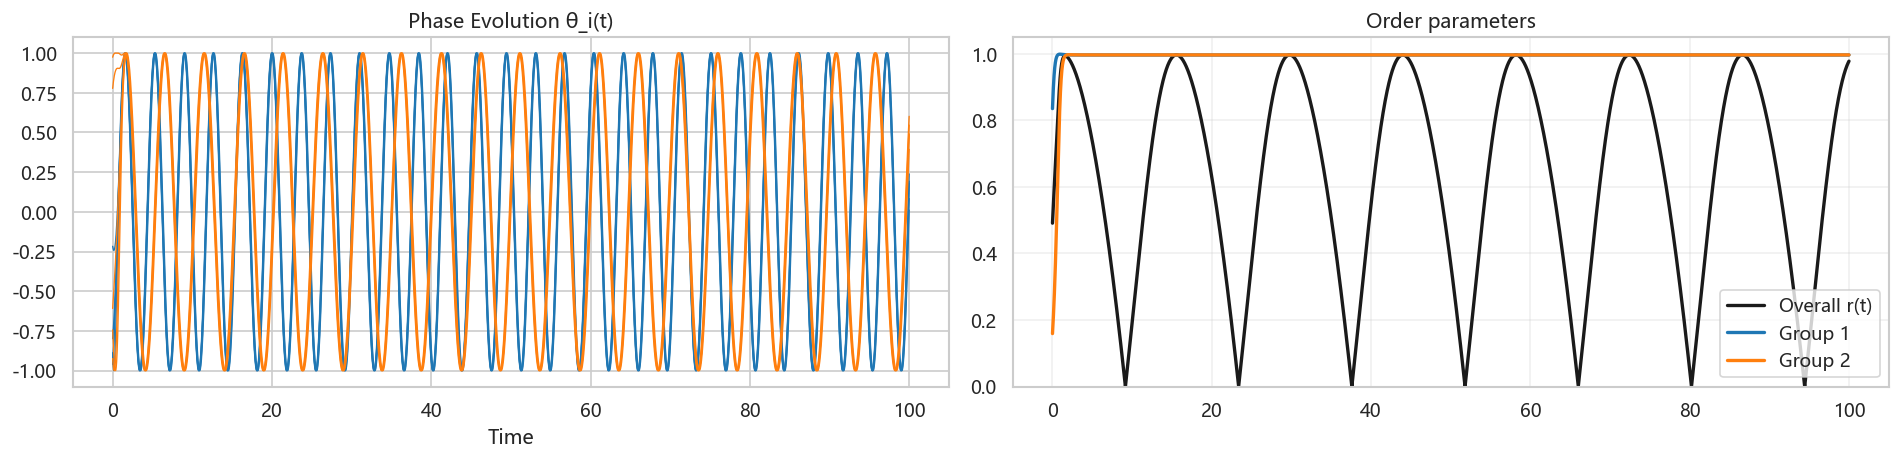

Clean micro data shape: (10000, 20)
Noisy micro data shape: (10000, 20)
Theta history shape: (10000, 10)


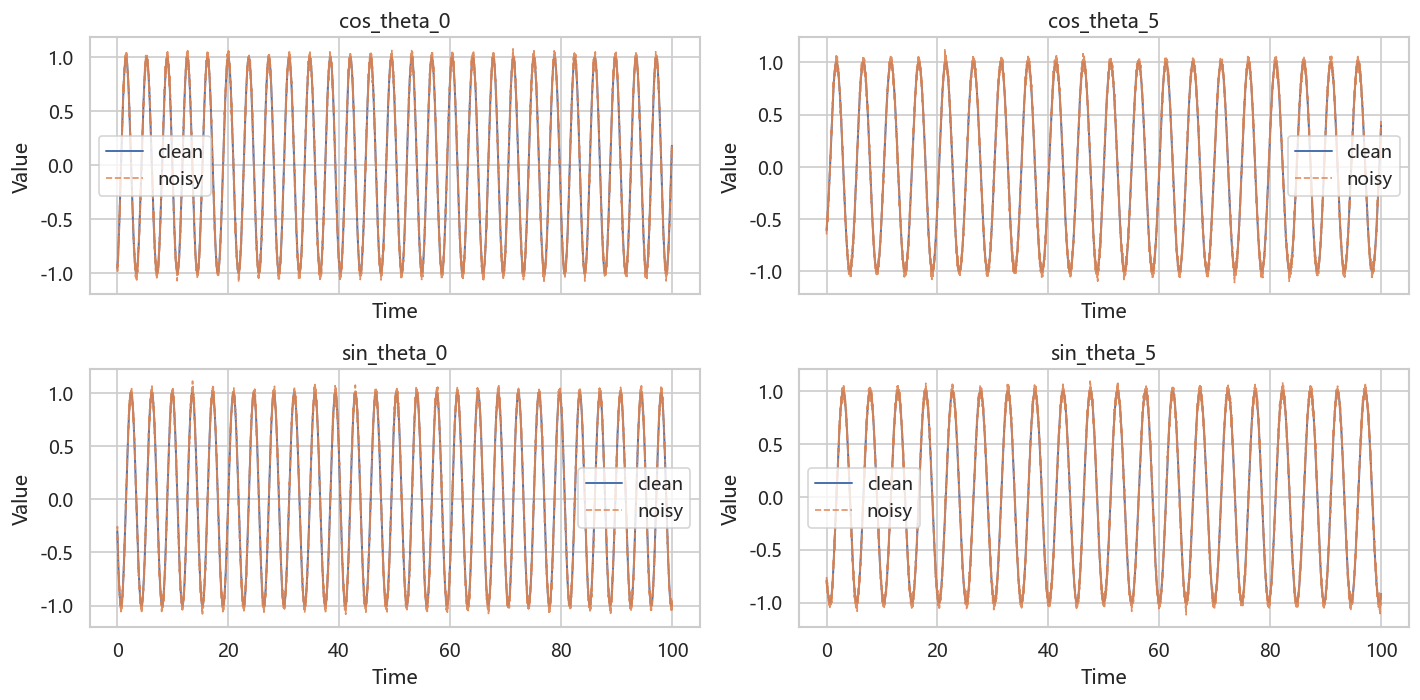

In [4]:
x_data_clean, theta_hist, t_data_raw, K_matrix_true = plot_clustered_kuramoto(**config['kuramoto'])
noise_result = add_gaussian_noise(x_data_clean, noise_scale=config['noise_scale'], cov=None, random_state=config['noise_seed'])
x_data_noisy = noise_result['noisy_data']

n_osc = config['kuramoto']['N']
state_names_raw = [f'cos_theta_{i}' for i in range(n_osc)] + [f'sin_theta_{i}' for i in range(n_osc)]
artifacts['raw'] = {'x_data_clean': x_data_clean, 'x_data_noisy': x_data_noisy, 'theta_hist': theta_hist, 't_data_raw': t_data_raw, 'K_matrix_true': K_matrix_true, 'state_names_raw': state_names_raw}

print('Clean micro data shape:', x_data_clean.shape)
print('Noisy micro data shape:', x_data_noisy.shape)
print('Theta history shape:', theta_hist.shape)

fig, axes = plt.subplots(2, 2, figsize=(12, 6), sharex=True)
axes = np.asarray(axes).ravel()
for ax, idx in zip(axes, config['selected_micro_indices']):
    ax.plot(t_data_raw, x_data_clean[:, idx], linewidth=1.2, label='clean')
    ax.plot(t_data_raw, x_data_noisy[:, idx], '--', linewidth=1.0, alpha=0.9, label='noisy')
    ax.set_title(state_names_raw[idx])
    ax.set_xlabel('Time')
    ax.set_ylabel('Value')
    ax.legend()
plt.tight_layout(); plt.show()


### 1.2 ?????ide+fourier???????????

???? `identity + fourier` ???????? `sin/cos` ???? lift ??????????
$$
\mathbf{o}_t = g(\mathbf{x}_t).
$$
???????? `lag_steps`???????
$$
(\mathbf{o}_t, \mathbf{o}_{t+\tau}).
$$


Prepared micro data shape: (900, 20)
Lifted observation shape: (900, 60)
Pair shape: (888, 60) (888, 60)
Physical tau = 1.2000000000000002
First 12 feature names: ['cos_theta_0', 'cos_theta_1', 'cos_theta_2', 'cos_theta_3', 'cos_theta_4', 'cos_theta_5', 'cos_theta_6', 'cos_theta_7', 'cos_theta_8', 'cos_theta_9', 'sin_theta_0', 'sin_theta_1']


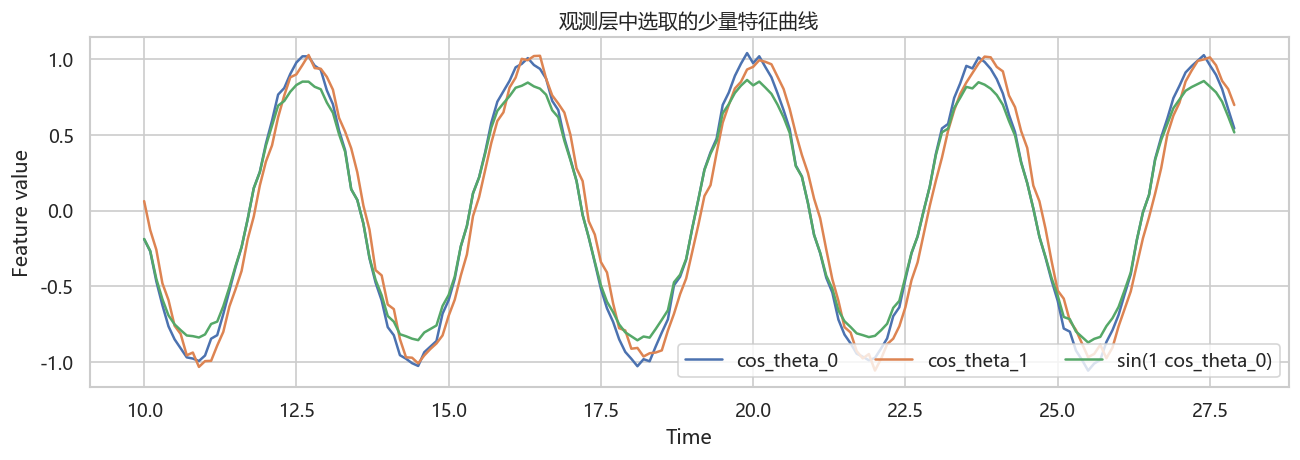

In [5]:
burn_in_steps, sample_stride, lag_steps = config['burn_in_steps'], config['sample_stride'], config['lag_steps']
x_data_fit = x_data_noisy[burn_in_steps::sample_stride].copy()
theta_fit = theta_hist[burn_in_steps::sample_stride].copy()
t_data_fit = t_data_raw[burn_in_steps::sample_stride].copy()
dt_fit = config['kuramoto']['dt'] * sample_stride
tau_phys = lag_steps * dt_fit

obs_result = observable_identity_fourier(x_data_fit, state_names=state_names_raw, n_frequencies=config['n_fourier_frequencies'])
obs_data = obs_result['data']
feature_names = obs_result['feature_names']
X_now, X_next = prepare_time_pairs(obs_data, tau=lag_steps, burn_in=0, stride=1)
valid_feature_indices = [idx for idx in config['selected_feature_plot_indices'] if idx < obs_data.shape[1]]

artifacts['prep'] = {'x_data_fit': x_data_fit, 'theta_fit': theta_fit, 't_data_fit': t_data_fit, 'dt_fit': dt_fit, 'tau_phys': tau_phys, 'X_now': X_now, 'X_next': X_next}
artifacts['obs'] = {'obs_data': obs_data, 'feature_names': feature_names, 'library': obs_result['library']}

print('Prepared micro data shape:', x_data_fit.shape)
print('Lifted observation shape:', obs_data.shape)
print('Pair shape:', X_now.shape, X_next.shape)
print('Physical tau =', tau_phys)
print('First 12 feature names:', feature_names[:12])

plt.figure(figsize=(11, 4))
for idx in valid_feature_indices:
    plt.plot(t_data_fit[:config['curve_window']], obs_data[:config['curve_window'], idx], linewidth=1.5, label=feature_names[idx])
plt.title('观测层中选取的少量特征曲线')
plt.xlabel('Time'); plt.ylabel('Feature value'); plt.legend(ncol=3); plt.tight_layout(); plt.show()


### 1.3 ??? A/K_raw ? Sigma ???

????????????? `GIS`?
$$
\mathbf{o}_{t+\tau} \approx \mathbf{A}_o \mathbf{o}_t + \boldsymbol{\varepsilon}^{(o)}_t,
\qquad
\boldsymbol{\Sigma}_o = \operatorname{Cov}(\boldsymbol{\varepsilon}^{(o)}_t).
$$
?????? `A` ? `K_raw`????? notebook ???


A_micro shape: (60, 60)
K_raw_micro shape: (60, 60)
Sigma_micro shape: (60, 60)
||A - K_raw^T||_F = 0.0


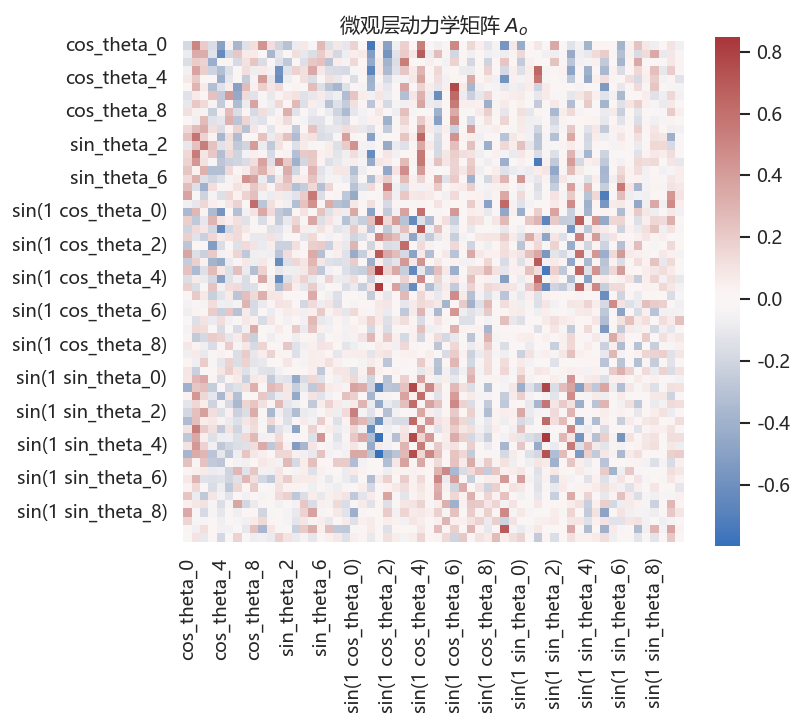

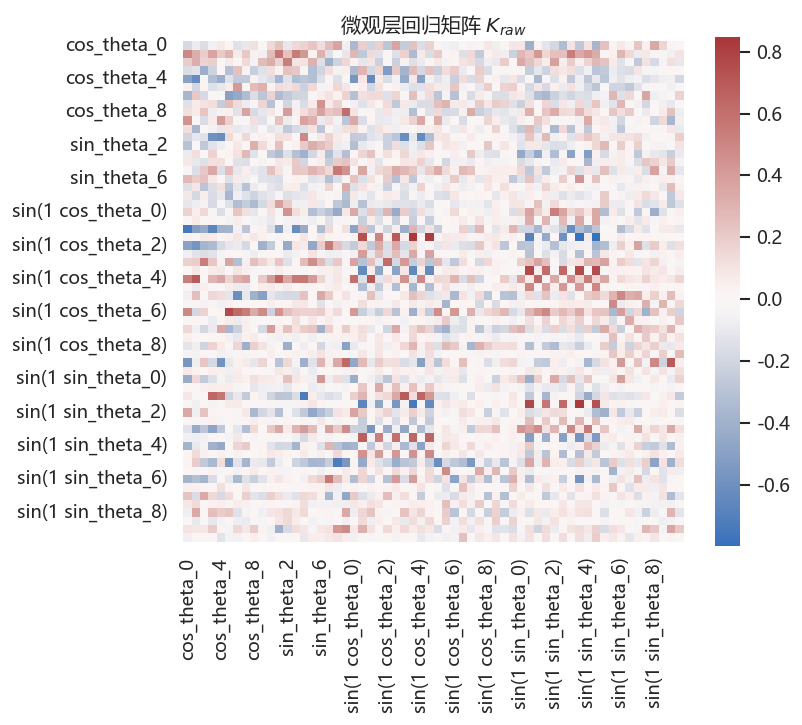

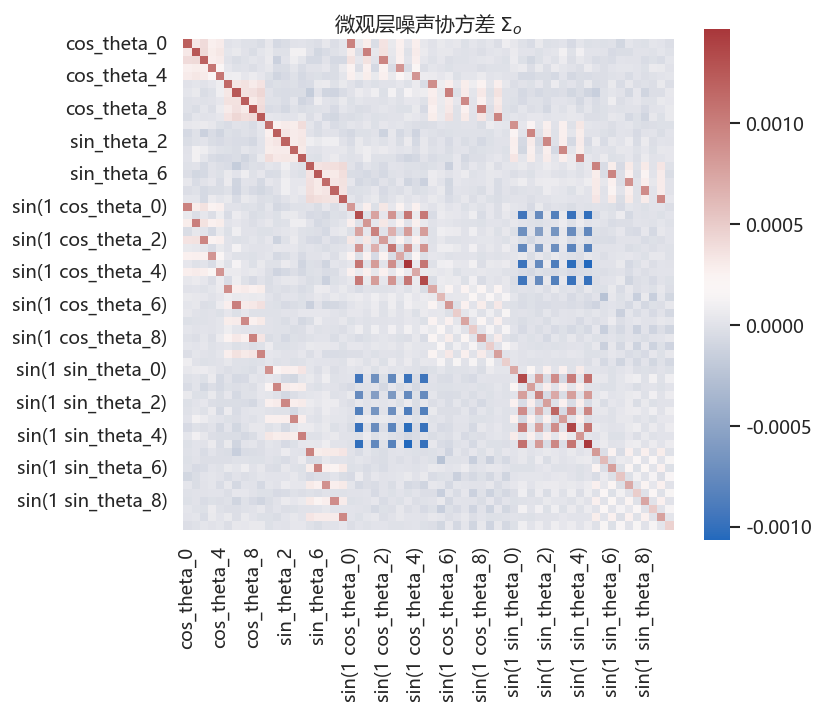

In [6]:
micro_fit = fit_linear_gis_from_pairs(X_now, X_next, fit_intercept=False, ridge=config['ridge'], regularization=config['eps'])
A_micro, K_raw_micro, Sigma_micro = micro_fit['A'], micro_fit['K_raw'], micro_fit['Sigma']
artifacts['micro_fit'] = micro_fit

print('A_micro shape:', A_micro.shape)
print('K_raw_micro shape:', K_raw_micro.shape)
print('Sigma_micro shape:', Sigma_micro.shape)
print('||A - K_raw^T||_F =', np.linalg.norm(A_micro - K_raw_micro.T))

plot_matrix_heatmap(A_micro, '微观层动力学矩阵 $A_o$', row_labels=feature_names, col_labels=feature_names, label_step=config['micro_label_step'], figsize=config['matrix_figsize'])
plot_matrix_heatmap(K_raw_micro, '微观层回归矩阵 $K_{raw}$', row_labels=feature_names, col_labels=feature_names, label_step=config['micro_label_step'], figsize=config['matrix_figsize'])
plot_matrix_heatmap(Sigma_micro, '微观层噪声协方差 $\Sigma_o$', row_labels=feature_names, col_labels=feature_names, center=None, label_step=config['micro_label_step'], figsize=config['matrix_figsize'])


### 1.4 微观层预测与误差

得到微观层 `A_o` 后，分别计算单步与多步滚动预测误差，检查当前观测空间和时间尺度下的闭合性。画图时仍然只挑少数几个观测特征，避免曲线过密。


,horizon,mean_error
0,1,0.056949
1,3,0.113624
2,5,0.184531


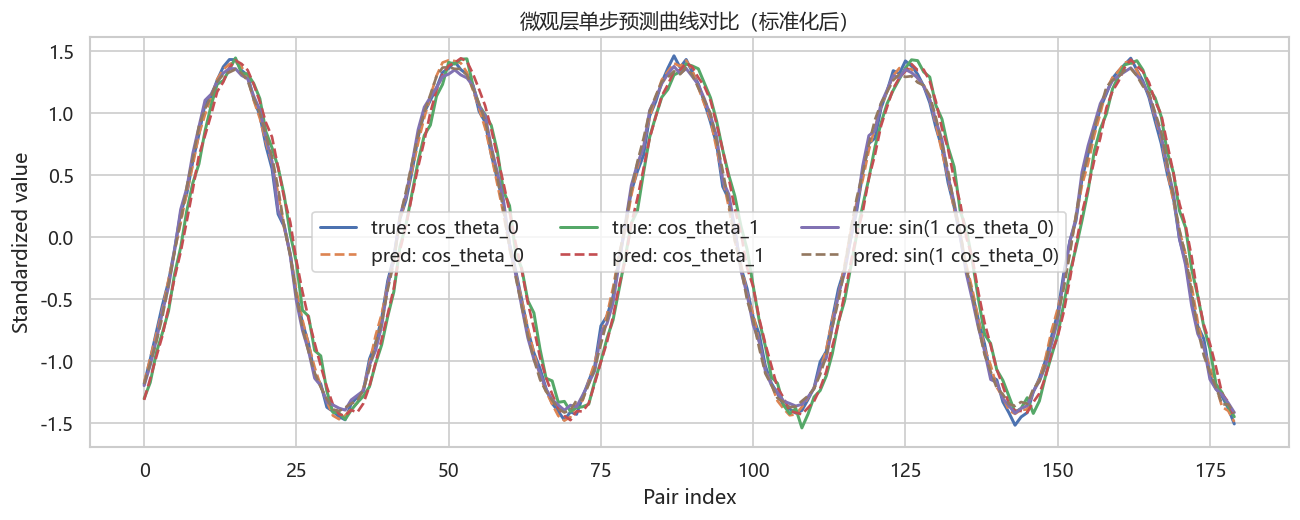

In [7]:
errors_micro = compute_prediction_errors(A_micro, obs_data, tau=lag_steps, horizons=config['horizons'])
micro_error_table = pd.DataFrame({'horizon': list(errors_micro.keys()), 'mean_error': [errors_micro[h]['mean_error'] for h in errors_micro.keys()]})
display(micro_error_table)

pred1_micro, true1_micro = errors_micro[1]['predictions'], errors_micro[1]['targets']
plt.figure(figsize=(11, 4.5))
for idx in valid_feature_indices:
    plt.plot(standardize_for_plot(true1_micro[:config['curve_window'], idx]), linewidth=1.8, label=f'true: {feature_names[idx]}')
    plt.plot(standardize_for_plot(pred1_micro[:config['curve_window'], idx]), '--', linewidth=1.6, label=f'pred: {feature_names[idx]}')
plt.title('微观层单步预测曲线对比（标准化后）')
plt.xlabel('Pair index'); plt.ylabel('Standardized value'); plt.legend(ncol=3); plt.tight_layout(); plt.show()


### 1.5 ??? GIS ??

????????
$$
\Gamma_{\alpha}^{\mathrm{GIS}}, \quad
\log \Gamma_{\alpha}^{\mathrm{GIS}}, \quad
J_{\alpha}^{\mathrm{GIS}} = \frac{1}{d} \log \Gamma_{\alpha}^{\mathrm{GIS}},
$$
?? `D` ? `N`??????????? $\boldsymbol{\Sigma}^{-1}$ ????? $\mathbf{A}^\top \boldsymbol{\Sigma}^{-1} \mathbf{A}$ ??????????????


,metric,value
0,Gamma,4.155730e+88
1,log_Gamma,2.040520e+02
2,J_alpha,3.400866e+00
3,D,5.015594e+02
4,N,3.146485e+02


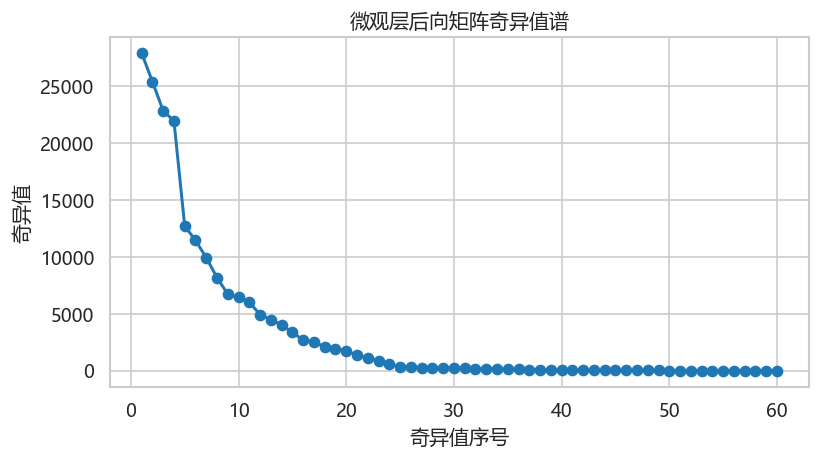

In [8]:
metrics_micro = compute_gis_metrics(A_micro, Sigma_micro, alpha=config['alpha'], eps=config['eps'])
display(pd.DataFrame([
    {'metric': 'Gamma', 'value': metrics_micro['Gamma']},
    {'metric': 'log_Gamma', 'value': metrics_micro['log_Gamma']},
    {'metric': 'J_alpha', 'value': metrics_micro['J_alpha']},
    {'metric': 'D', 'value': metrics_micro['D']},
    {'metric': 'N', 'value': metrics_micro['N']},
]))
plot_dual_singular_spectra(
    metrics_micro['sv_forward'],
    metrics_micro['sv_backward'],
    title='?????/???????',
    forward_label=r'???? $\Sigma^{-1}$',
    backward_label=r'???? $A^\top \Sigma^{-1} A$',
)


### 1.6 宏观维度选择与 W 的构造

宏观变量由线性粗粒化给出：
$$
\mathbf{z}_t = \mathbf{W}\mathbf{o}_t.
$$
这里沿用 `SVD` 路线，从微观层谱结构选择宏观维度 `r` 并构造粗粒化矩阵 `W`。热力图使用稀疏标签，同时补一个主导特征表帮助解释宏观变量由哪些观测分量组成。


,macro_component,feature,weight,abs_weight
0,z_1,sin(1 cos_theta_2),-0.373991,0.373991
1,z_1,sin(1 sin_theta_9),-0.344629,0.344629
2,z_1,cos_theta_2,0.287466,0.287466
3,z_1,sin_theta_9,0.275261,0.275261
4,z_1,sin(1 cos_theta_5),-0.261685,0.261685
5,z_2,sin(1 cos_theta_1),-0.280230,0.280230
6,z_2,sin(1 cos_theta_4),0.276111,0.276111
7,z_2,sin(1 cos_theta_0),-0.272005,0.272005
8,z_2,sin(1 sin_theta_4),-0.258049,0.258049
9,z_2,sin(1 cos_theta_7),0.241562,0.241562


Selected macro rank r = 2


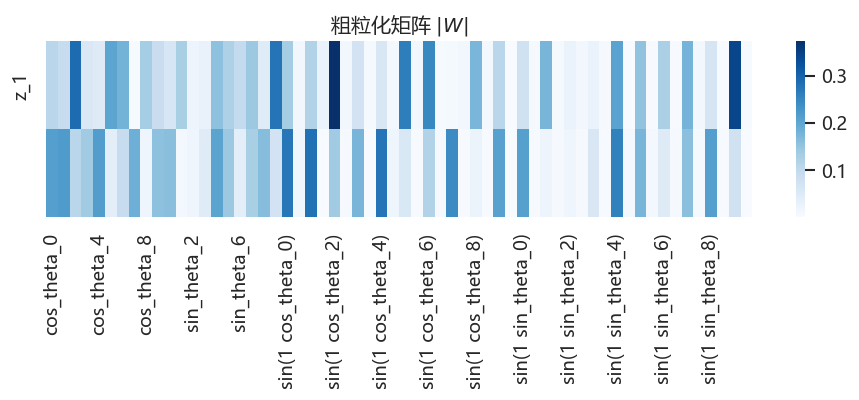

In [9]:
selected_r, rank_meta = select_macro_rank(metrics_micro['sv_backward'], mode='manual', manual_r=config['manual_r'], eps=config['eps'])
W = build_w_from_svd(A_micro, Sigma_micro, r=selected_r, alpha=config['alpha'], eps=config['eps'], mode='two_stage')['W']
macro_names = [f'z_{i + 1}' for i in range(selected_r)]

dominant_rows = []
for comp_idx in range(W.shape[0]):
    weights = np.abs(W[comp_idx])
    order_idx = np.argsort(-weights)
    for feat_idx in order_idx[:5]:
        dominant_rows.append({'macro_component': macro_names[comp_idx], 'feature': feature_names[feat_idx], 'weight': W[comp_idx, feat_idx], 'abs_weight': weights[feat_idx]})
display(pd.DataFrame(dominant_rows))
artifacts['macro']['W'] = W
artifacts['macro']['rank_meta'] = rank_meta

print('Selected macro rank r =', selected_r)
plot_matrix_heatmap(np.abs(W), '粗粒化矩阵 $|W|$', row_labels=macro_names, col_labels=feature_names, center=None, label_step=config['micro_label_step'], figsize=(8, 3.5), cmap='Blues')


### 1.7 宏观数据生成

得到 `W` 之后，把观测层时间序列映射到宏观层：
$$
\mathbf{z}_t = \mathbf{W}\mathbf{o}_t.
$$
这一步把候选宏观表示真正落成数据序列，并构造宏观层配对样本 `(z_t, z_{t+τ})`。


Macro data shape: (900, 2)
Macro pair shape: (888, 2) (888, 2)


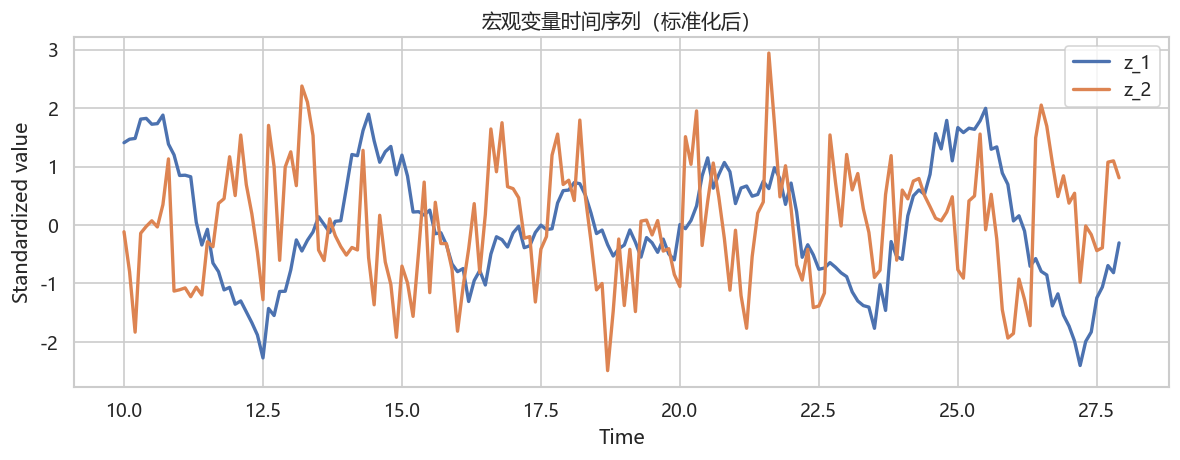

In [10]:
z_data = apply_coarse_graining(W, obs_data)
Z_now, Z_next = prepare_time_pairs(z_data, tau=lag_steps, burn_in=0, stride=1)
artifacts['macro']['z_data'] = z_data
artifacts['macro']['Z_now'] = Z_now
artifacts['macro']['Z_next'] = Z_next

print('Macro data shape:', z_data.shape)
print('Macro pair shape:', Z_now.shape, Z_next.shape)
plt.figure(figsize=(10, 4))
for idx, name in enumerate(macro_names):
    plt.plot(t_data_fit[:config['curve_window']], standardize_for_plot(z_data[:config['curve_window'], idx]), linewidth=2.0, label=name)
plt.title('宏观变量时间序列（标准化后）')
plt.xlabel('Time'); plt.ylabel('Standardized value'); plt.legend(); plt.tight_layout(); plt.show()


### 1.8 ?????

?????????????????????
$$
\mathbf{z}_{t+\tau} \approx \mathbf{A}_z \mathbf{z}_t + \boldsymbol{\varepsilon}^{(z)}_t,
\qquad
\boldsymbol{\Sigma}_z = \operatorname{Cov}(\boldsymbol{\varepsilon}^{(z)}_t).
$$
???????????? `GIS`??????????


A_macro shape: (2, 2)
K_raw_macro shape: (2, 2)
Sigma_macro shape: (2, 2)


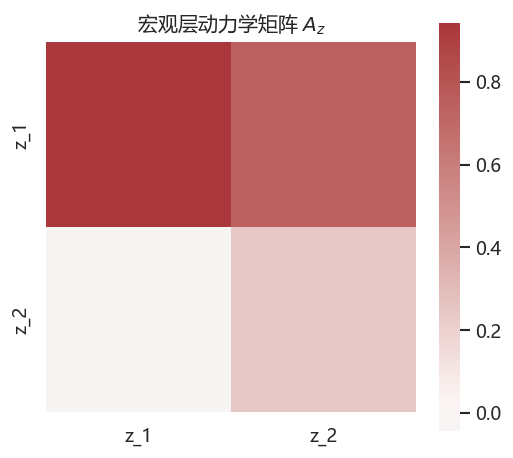

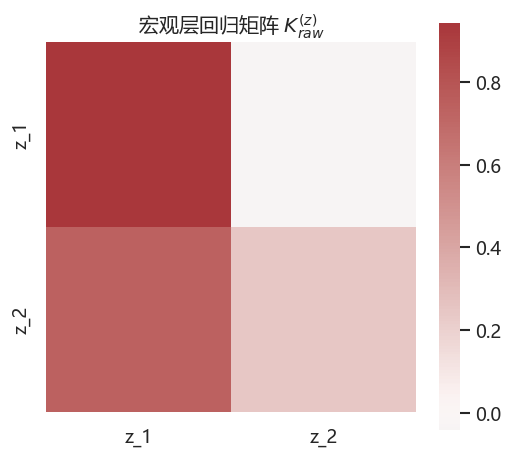

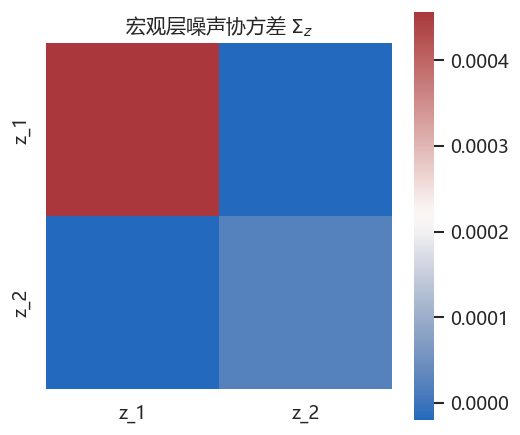

In [11]:
macro_fit = fit_linear_gis_from_pairs(Z_now, Z_next, fit_intercept=False, ridge=config['ridge'], regularization=config['eps'])
A_macro, K_raw_macro, Sigma_macro = macro_fit['A'], macro_fit['K_raw'], macro_fit['Sigma']
artifacts['macro_fit'] = macro_fit

print('A_macro shape:', A_macro.shape)
print('K_raw_macro shape:', K_raw_macro.shape)
print('Sigma_macro shape:', Sigma_macro.shape)
plot_matrix_heatmap(A_macro, '宏观层动力学矩阵 $A_z$', row_labels=macro_names, col_labels=macro_names, label_step=1, figsize=(4.5, 4.0))
plot_matrix_heatmap(K_raw_macro, '宏观层回归矩阵 $K_{raw}^{(z)}$', row_labels=macro_names, col_labels=macro_names, label_step=1, figsize=(4.5, 4.0))
plot_matrix_heatmap(Sigma_macro, '宏观层噪声协方差 $\Sigma_z$', row_labels=macro_names, col_labels=macro_names, center=None, label_step=1, figsize=(4.5, 4.0))


### 1.9 宏观层预测、误差

如果宏观层是合理的压缩表示，那么它不应只在指标上变好，还应该保持足够好的预测闭合性。因此这里同样给出单步与多步误差，并画出宏观层一步预测对比曲线。


,horizon,mean_error
0,1,0.000503
1,3,0.000374
2,5,0.000822


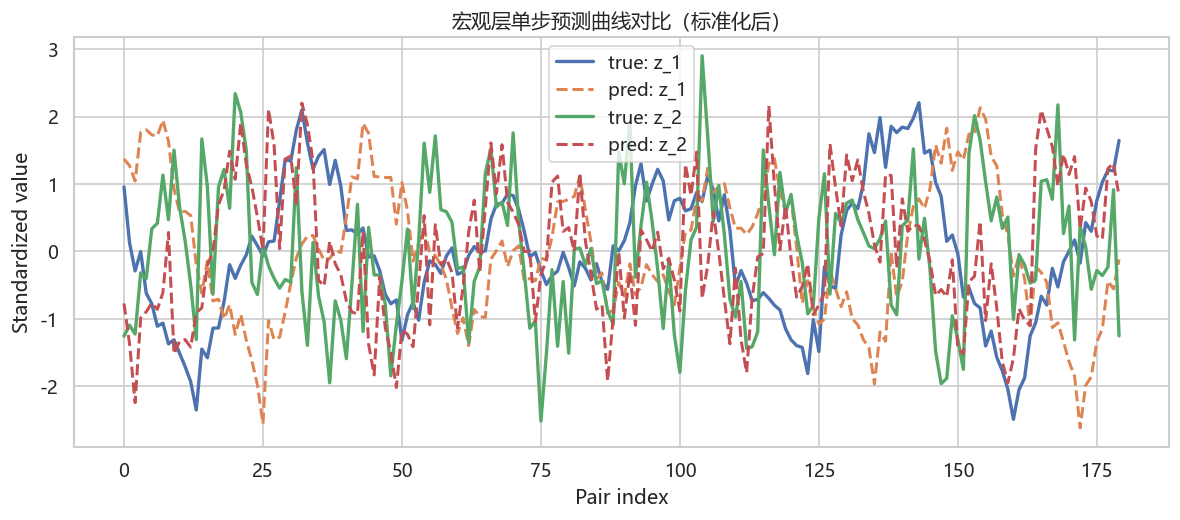

In [12]:
errors_macro = compute_prediction_errors(A_macro, z_data, tau=lag_steps, horizons=config['horizons'])
macro_error_table = pd.DataFrame({'horizon': list(errors_macro.keys()), 'mean_error': [errors_macro[h]['mean_error'] for h in errors_macro.keys()]})
display(macro_error_table)

pred1_macro, true1_macro = errors_macro[1]['predictions'], errors_macro[1]['targets']
plt.figure(figsize=(10, 4.5))
for idx, name in enumerate(macro_names):
    plt.plot(standardize_for_plot(true1_macro[:config['curve_window'], idx]), linewidth=2.0, label=f'true: {name}')
    plt.plot(standardize_for_plot(pred1_macro[:config['curve_window'], idx]), '--', linewidth=1.8, label=f'pred: {name}')
plt.title('宏观层单步预测曲线对比（标准化后）')
plt.xlabel('Pair index'); plt.ylabel('Standardized value'); plt.legend(); plt.tight_layout(); plt.show()


### 1.10 宏观层GIS指标

宏观层同样计算 `Gamma`、`log_Gamma`、`J_alpha`、`D` 和 `N`。这一步不能省略，因为 `CE` 不是宏观层单独的分数，而是宏观层相对微观层的维度平均效率提升。


,metric,value
0,Gamma,5137.259141
1,log_Gamma,8.544275
2,J_alpha,4.272137
3,D,18.436430
4,N,15.740670


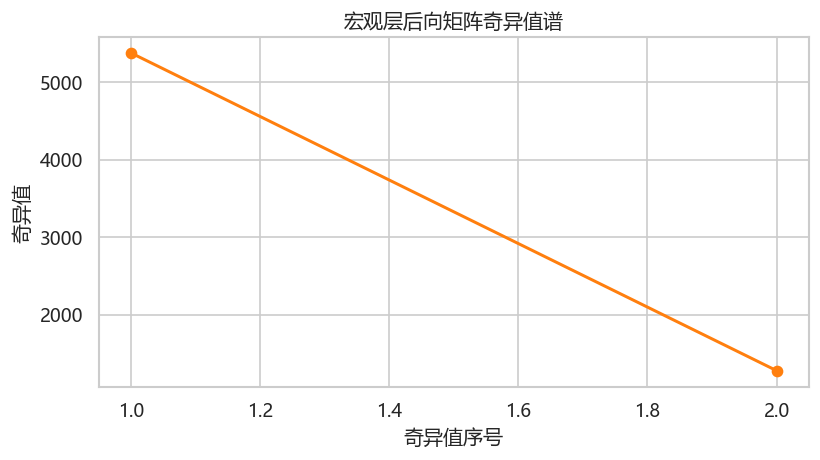

In [13]:
metrics_macro = compute_gis_metrics(A_macro, Sigma_macro, alpha=config['alpha'], eps=config['eps'])
display(pd.DataFrame([
    {'metric': 'Gamma', 'value': metrics_macro['Gamma']},
    {'metric': 'log_Gamma', 'value': metrics_macro['log_Gamma']},
    {'metric': 'J_alpha', 'value': metrics_macro['J_alpha']},
    {'metric': 'D', 'value': metrics_macro['D']},
    {'metric': 'N', 'value': metrics_macro['N']},
]))
plot_dual_singular_spectra(
    metrics_macro['sv_forward'],
    metrics_macro['sv_backward'],
    title='?????/???????',
    forward_label=r'???? $\Sigma_z^{-1}$',
    backward_label=r'???? $A_z^\top \Sigma_z^{-1} A_z$',
    forward_color='#54A24B',
    backward_color='#E45756',
)


### 1.11 CE?+???????

?????????????
$$
\mathrm{CE} = J_{\alpha,z} - J_{\alpha,o}.
$$
? `CE > 0`?????????????????????????????????????????????


CE = 0.8712712178888582
delta_D = -483.122989503437
delta_N = -298.9078153305935


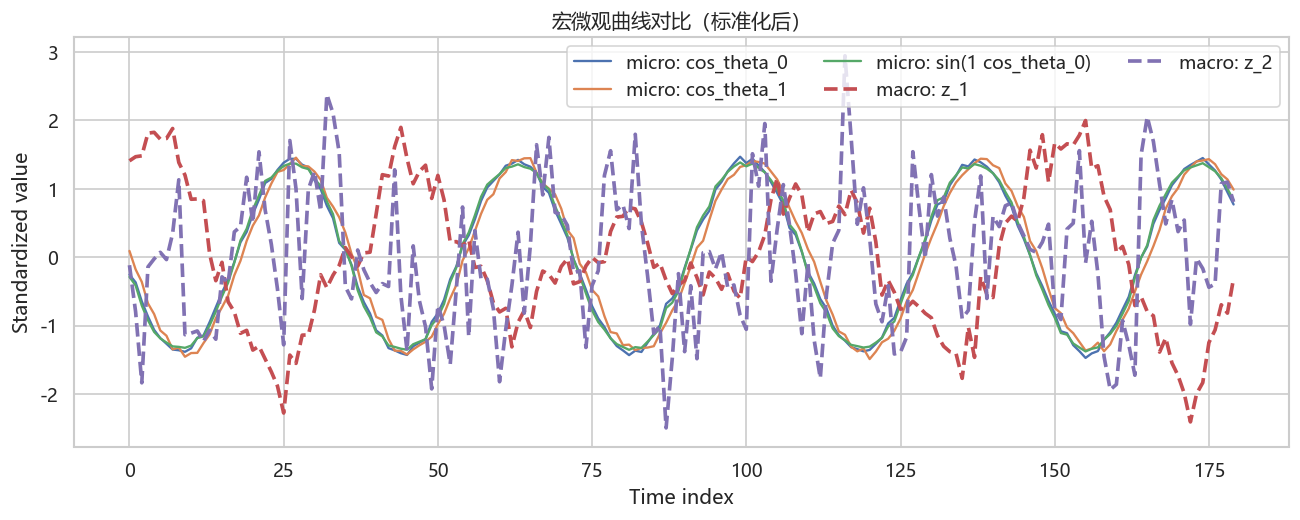

In [14]:
ce_result = compute_ce_from_micro_macro(metrics_micro, metrics_macro)
print('CE =', ce_result['CE'])
print('delta_D =', ce_result['delta_D'])
print('delta_N =', ce_result['delta_N'])

plt.figure(figsize=(11, 4.5))
for idx in valid_feature_indices:
    plt.plot(np.arange(config['curve_window']), standardize_for_plot(obs_data[:config['curve_window'], idx]), linewidth=1.4, label=f'micro: {feature_names[idx]}')
for idx, name in enumerate(macro_names):
    plt.plot(np.arange(config['curve_window']), standardize_for_plot(z_data[:config['curve_window'], idx]), '--', linewidth=2.2, label=f'macro: {name}')
plt.title('宏微观曲线对比（标准化后）')
plt.xlabel('Time index'); plt.ylabel('Standardized value'); plt.legend(ncol=3); plt.tight_layout(); plt.show()


### 1.12 结果汇总

这一块把第一部分主流程里的关键结果压缩成一条记录，便于后续做参数扫描、噪声扫描或者与别的系统横向比较。


In [15]:
summary_dict, summary_row = summarize_pipeline_results(
    config={'experiment_name': config['experiment_name'], 'tau': tau_phys, 'delta': None, 'alpha': config['alpha'], 'noise_scale': config['noise_scale']},
    micro_fit=micro_fit,
    macro_fit=macro_fit,
    micro_metrics=metrics_micro,
    macro_metrics=metrics_macro,
    prediction_results={'micro_errors': errors_micro, 'macro_errors': errors_macro},
    ce_result=ce_result,
    extra={'W': W, 'rank_meta': rank_meta, 'observable_mode': config['observable_mode'], 'feature_names': feature_names, 'macro_names': macro_names},
)
artifacts['summary']['main_pipeline'] = summary_dict
display(pd.DataFrame([summary_row]))


,experiment_name,tau,alpha,delta,noise_scale,micro_dim,macro_dim,micro_J_alpha,macro_J_alpha,micro_D,...,micro_N,macro_N,micro_log_Gamma,macro_log_Gamma,CE,delta_D,delta_N,delta_log_Gamma,micro_E1,macro_E1
0,exp_kuramoto_gis,1.2,1.0,None,0.03,60,2,3.400866,4.272137,501.55942,...,314.648485,15.74067,204.051976,8.544275,0.871271,-483.12299,-298.907815,-195.507701,0.056949,0.000503


## 第二部分：实验特有部分（主要参考 `exp_kuramoto_0321.ipynb`）

第一部分给出了标准 `GIS` 主流程。这里补的是 `Kuramoto` 旧实验里非常有辨识度的两项分析：互信息占比与频谱分析。它们不直接定义 `CE`，但能帮助判断宏观压缩到底丢了什么、保留了什么。


### 2.1 ?????

???????????????????????? $X_t$ ?????? $X_{t+\tau}$ ?????`SVD` ?????? $Z_t$ ?????????????? $K_{\mathrm{bar}}$ ????????????? $Z_t^{\mathrm{eig}}$ ???????????

????????
$$
\rho_{\mathrm{MI}}(Z) = \frac{I(Z_t; X_{t+\tau})}{I(X_t; X_{t+\tau})}.
$$


,name,symbol,value,ratio_to_micro
0,SVD ??????????,I(Z_t; X_{t+tau}),1.878610,0.062178
1,EVD ??????????,I(Z_t^eig; X_{t+tau}),2.607458,0.086301
2,???????????,I(X_t; X_{t+tau}),30.213416,1.000000


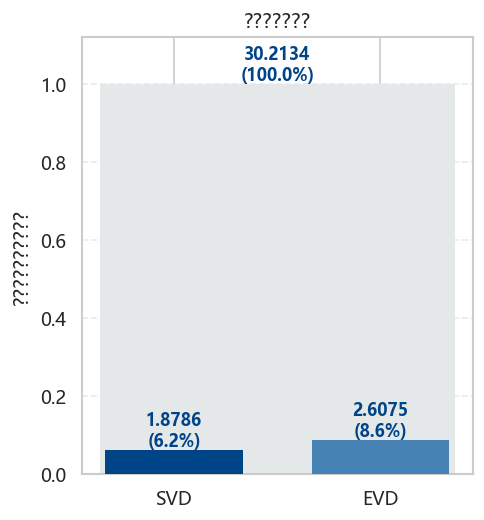

,component,feature,weight,abs_weight
0,eig_z_1,sin_theta_9,0.118356,0.118356
1,eig_z_1,cos(1 cos_theta_8),0.091705,0.091705
2,eig_z_1,sin(1 sin_theta_9),-0.090617,0.090617
3,eig_z_1,cos(1 sin_theta_4),0.083266,0.083266
4,eig_z_1,cos(1 cos_theta_6),0.081137,0.081137
5,eig_z_2,sin(1 cos_theta_1),-1.561673,1.561673
6,eig_z_2,sin(1 sin_theta_1),1.371484,1.371484
7,eig_z_2,sin(1 sin_theta_3),-1.155939,1.155939
8,eig_z_2,sin(1 cos_theta_3),0.801486,0.801486
9,eig_z_2,cos_theta_3,0.722240,0.722240


In [16]:
koop_fit = fit_data_koopman_operator([obs_data], library=None, weights='uniform', eps=config['eps'], ridge=config['ridge'], lag_steps=lag_steps)
K_bar, C00_inv_sqrt = koop_fit['K_bar'], koop_fit['C00_inv_sqrt']
eig_macro = build_macro_from_kbar_eig(K_bar=K_bar, C00_inv_sqrt=C00_inv_sqrt, X=koop_fit['X'], r=selected_r, feature_names=feature_names, center=False)
z_eig_current = eig_macro['z_eig_current']

mi_x_to_xnext = gaussian_mutual_information(X_now, X_next, eps=config['eps'])
mi_z_to_xnext = gaussian_mutual_information(Z_now, X_next, eps=config['eps'])
mi_z_eig_to_xnext = gaussian_mutual_information(z_eig_current, X_next, eps=config['eps'])
mi_ratio_z = mi_z_to_xnext / mi_x_to_xnext if mi_x_to_xnext > 0 else np.nan
mi_ratio_z_eig = mi_z_eig_to_xnext / mi_x_to_xnext if mi_x_to_xnext > 0 else np.nan

mi_summary = pd.DataFrame([
    {'name': 'SVD ??????????', 'symbol': 'I(Z_t; X_{t+tau})', 'value': mi_z_to_xnext, 'ratio_to_micro': mi_ratio_z},
    {'name': 'EVD ??????????', 'symbol': 'I(Z_t^eig; X_{t+tau})', 'value': mi_z_eig_to_xnext, 'ratio_to_micro': mi_ratio_z_eig},
    {'name': '???????????', 'symbol': 'I(X_t; X_{t+tau})', 'value': mi_x_to_xnext, 'ratio_to_micro': 1.0},
])
display(mi_summary)

fig, ax = plt.subplots(figsize=(4.2, 4.5))
center_x, offset = 0.0, 0.18
sub_x = np.array([center_x - offset, center_x + offset])
ratio_values, raw_values = [mi_ratio_z, mi_ratio_z_eig], [mi_z_to_xnext, mi_z_eig_to_xnext]
ax.bar([center_x], [1.0], width=0.62, color='#E5E8E8', edgecolor='none', zorder=1)
sub_bars = ax.bar(sub_x, ratio_values, width=0.24, color=['#004488', '#4682B4'], edgecolor='none', zorder=3)
ax.text(center_x, 1.0, f'{mi_x_to_xnext:.4f}\n(100.0%)', ha='center', va='bottom', fontsize=10, fontweight='bold', color='#004488')
for bar, raw_value, ratio in zip(sub_bars, raw_values, ratio_values):
    ax.text(bar.get_x() + bar.get_width() / 2.0, bar.get_height(), f'{raw_value:.4f}\n({ratio * 100:.1f}%)', ha='center', va='bottom', fontsize=10, fontweight='bold', color='#004488')
ax.set_xticks(sub_x); ax.set_xticklabels(['SVD', 'EVD'])
ax.set_ylim(0, max(1.12, np.nanmax([1.0] + ratio_values) + 0.12))
ax.set_ylabel('??????????'); ax.set_title('???????'); ax.grid(True, axis='y', linestyle='--', alpha=0.4)
plt.tight_layout(); plt.show()

if eig_macro['dominant_features']:
    display(pd.DataFrame(eig_macro['dominant_features']))
artifacts['metrics']['mi_summary'] = mi_summary
artifacts['metrics']['mi_ratio_z'] = mi_ratio_z
artifacts['metrics']['mi_ratio_z_eig'] = mi_ratio_z_eig


### 2.2 ???????

???????????????????????????????????????????????????????????????????

?????????
$$
\hat{x}(f_k) = \sum_{n=0}^{N-1} x_n e^{-2\pi i kn / N}.
$$
????????????????


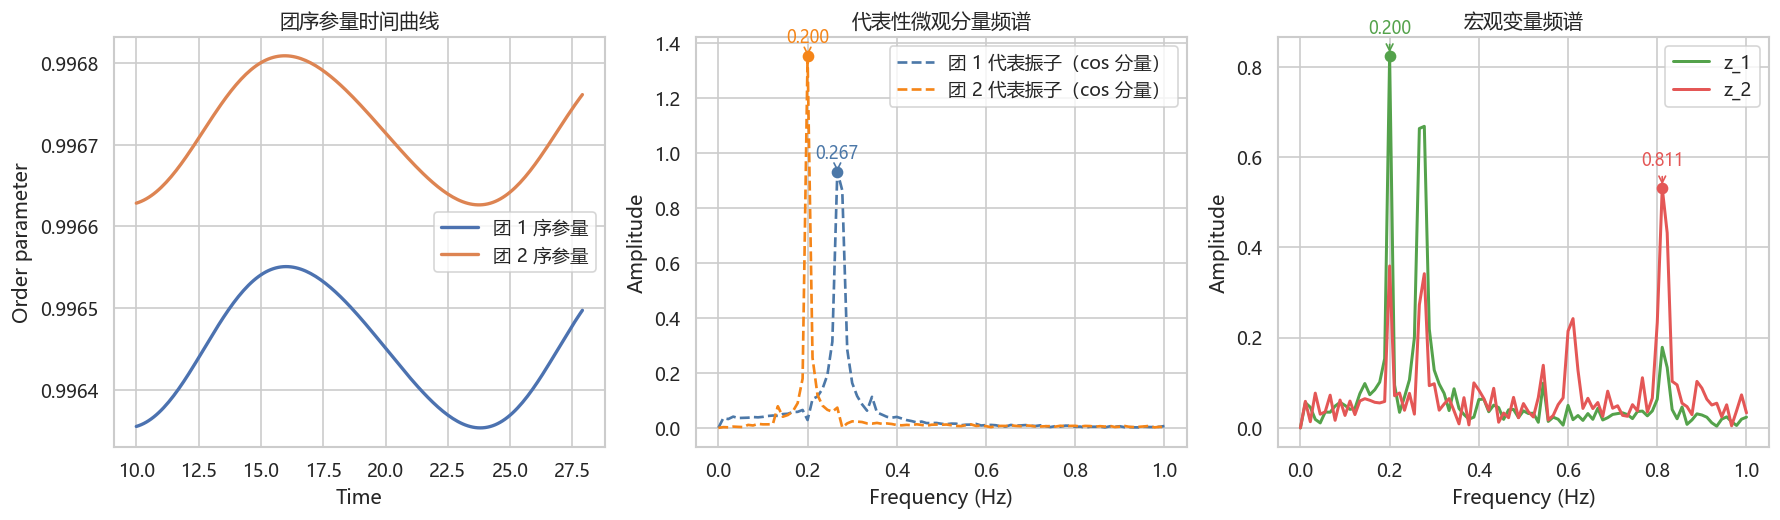

,group,label,peak_frequency,peak_amplitude
0,micro_1,团 1 代表振子（cos 分量）,0.266667,0.933417
1,micro_2,团 2 代表振子（cos 分量）,0.200000,1.354615
2,macro_1,z_1,0.200000,0.824665
3,macro_2,z_2,0.811111,0.531712


In [17]:
cluster_size = config['kuramoto']['N'] // config['kuramoto']['n_clusters']
representative_indices = [c * cluster_size for c in range(config['kuramoto']['n_clusters'])]
representative_labels = [f'? {c + 1} ?????cos ???' for c in range(config['kuramoto']['n_clusters'])]

freq_limit = 1.0
spectrum_rows = []
micro_spectra, macro_spectra = [], []

micro_colors = ['#4C78A8', '#F58518']
for idx, osc_idx in enumerate(representative_indices):
    signal = standardize_for_plot(x_data_fit[:, osc_idx])
    freqs, amps = compute_fft_spectrum(signal, dt=dt_fit, remove_dc=True, standardize=False)
    mask = freqs <= freq_limit
    micro_spectra.append({'freqs': freqs[mask], 'amps': amps[mask], 'label': representative_labels[idx], 'color': micro_colors[idx % len(micro_colors)]})

macro_colors = ['#54A24B', '#E45756', '#72B7B2']
for idx, name in enumerate(macro_names):
    signal = standardize_for_plot(z_data[:, idx])
    freqs, amps = compute_fft_spectrum(signal, dt=dt_fit, remove_dc=True, standardize=False)
    mask = freqs <= freq_limit
    macro_spectra.append({'freqs': freqs[mask], 'amps': amps[mask], 'label': name, 'color': macro_colors[idx % len(macro_colors)]})

fig, ax = plt.subplots(figsize=(8, 4.5))
for item in micro_spectra:
    ax.bar(item['freqs'], item['amps'], width=0.01, alpha=0.25, color=item['color'])
    ax.plot(item['freqs'], item['amps'], linestyle='--', linewidth=1.6, color=item['color'], label=item['label'])
    peak_info = mark_peak(ax, item['freqs'], item['amps'], item['color'], text_offset=0.05)
    spectrum_rows.append({'group': 'micro', 'label': item['label'], 'peak_frequency': None if peak_info is None else peak_info['peak_frequency'], 'peak_amplitude': None if peak_info is None else peak_info['peak_amplitude']})
ax.set_title('????')
ax.set_xlabel('Frequency (Hz)'); ax.set_ylabel('Amplitude'); ax.legend(); plt.tight_layout(); plt.show()

fig, ax = plt.subplots(figsize=(8, 4.5))
for item in macro_spectra:
    ax.bar(item['freqs'], item['amps'], width=0.01, alpha=0.25, color=item['color'])
    ax.plot(item['freqs'], item['amps'], linewidth=1.8, color=item['color'], label=item['label'])
    peak_info = mark_peak(ax, item['freqs'], item['amps'], item['color'], text_offset=0.05)
    spectrum_rows.append({'group': 'macro', 'label': item['label'], 'peak_frequency': None if peak_info is None else peak_info['peak_frequency'], 'peak_amplitude': None if peak_info is None else peak_info['peak_amplitude']})
ax.set_title('????')
ax.set_xlabel('Frequency (Hz)'); ax.set_ylabel('Amplitude'); ax.legend(); plt.tight_layout(); plt.show()

fig, ax = plt.subplots(figsize=(9, 4.8))
for item in micro_spectra:
    ax.plot(item['freqs'], item['amps'], linestyle='--', linewidth=1.5, color=item['color'], label=f"micro: {item['label']}")
for item in macro_spectra:
    ax.plot(item['freqs'], item['amps'], linewidth=1.8, color=item['color'], label=f"macro: {item['label']}")
ax.set_title('?? + ??????')
ax.set_xlabel('Frequency (Hz)'); ax.set_ylabel('Amplitude'); ax.legend(ncol=2); plt.tight_layout(); plt.show()

spectrum_summary_df = pd.DataFrame(spectrum_rows)
display(spectrum_summary_df)
artifacts['metrics']['spectrum_summary'] = spectrum_summary_df


## 第三部分：结尾统一摘要

最后一块不再引入新计算，而是把第一部分和第二部分串起来解释。重点回答三个问题：宏观层是否在 `CE` 上优于微观层，这种优势是否伴随着可接受的预测闭合性，以及宏观变量在互信息与频谱上是否仍保留系统的主要集体结构。


### 3.1 统一结论

这里把核心数值统一打印出来，并给出一个简短的结论性说明，便于后续做表格汇总和实验横向对比。


In [18]:
final_summary_df = pd.DataFrame([{
    'micro_J_alpha': metrics_micro['J_alpha'],
    'macro_J_alpha': metrics_macro['J_alpha'],
    'CE': ce_result['CE'],
    'micro_error_h1': errors_micro[1]['mean_error'],
    'macro_error_h1': errors_macro[1]['mean_error'],
    'mi_ratio_svd': mi_ratio_z,
    'mi_ratio_evd': mi_ratio_z_eig,
}])
display(final_summary_df)

print('统一摘要：')
print(f"1. 微观层 J_alpha = {metrics_micro['J_alpha']:.6f}")
print(f"2. 宏观层 J_alpha = {metrics_macro['J_alpha']:.6f}")
print(f"3. CE = {ce_result['CE']:.6f}")
print(f"4. 微观层一步误差 = {errors_micro[1]['mean_error']:.6f}")
print(f"5. 宏观层一步误差 = {errors_macro[1]['mean_error']:.6f}")
print(f"6. SVD 宏观互信息占比 = {mi_ratio_z:.4%}")
print(f"7. EVD 宏观互信息占比 = {mi_ratio_z_eig:.4%}")
if ce_result['CE'] > 0:
    print('结论：当前参数下，宏观表示在单位维度意义上优于微观表示，存在正的宏观效率增益。')
else:
    print('结论：当前参数下，宏观表示没有带来正的宏观效率增益，需要重新检查时间尺度、噪声或宏观维度选择。')
print('补充判断：请结合预测误差、互信息占比和频谱主峰位置，一起判断这个宏观表示是否足够可信。')


,micro_J_alpha,macro_J_alpha,CE,micro_error_h1,macro_error_h1,mi_ratio_svd,mi_ratio_evd
0,3.400866,4.272137,0.871271,0.056949,0.000503,0.062178,0.086301


统一摘要：
1. 微观层 J_alpha = 3.400866
2. 宏观层 J_alpha = 4.272137
3. CE = 0.871271
4. 微观层一步误差 = 0.056949
5. 宏观层一步误差 = 0.000503
6. SVD 宏观互信息占比 = 6.2178%
7. EVD 宏观互信息占比 = 8.6301%
结论：当前参数下，宏观表示在单位维度意义上优于微观表示，存在正的宏观效率增益。
补充判断：请结合预测误差、互信息占比和频谱主峰位置，一起判断这个宏观表示是否足够可信。
